<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - **Main Notes 2026/01** (Francisco Förster Burón):  
>   - https://github.com/fforster/AS4501/tree/main
> - Valetino Gonzales:
>   - https://github.com/cefuente/astroinformatica
> - Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> Paula Caceres, Javiera Toro, Melissa FuenteAlba, ..

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astroML.datasets

rc_params = {
   'mathtext.fontset': 'cm',     # Set default mathtext font
   'font.family': 'STIXGeneral', # Set default font family
   'xtick.direction': 'in',      # Set default xtickdirecion
   'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
   'ytick.direction': 'in',      # Set default ytickdirecion
   'ytick.minor.visible': True,  # visibility of minor ticks on y-axis
   'grid.linestyle': ':',        # Set grid linestyle
   'grid.alpha': 0.6,            # Set grid transparency
   
}
plt.rcParams.update(rc_params)

Una regresion linea es una funcón escrita como

$$y \equiv f(x, \theta) = \theta_0 + \theta_1 x$$




We use the `astroML.datasets.generate_mu_z` module to create a dataset of redshift vs distance modulus
We are asumming that 

$$\mu = \theta_1 z + \theta_0$$

where $\mu$ is the distance modulus, $z$ is the redshift, and $\theta$ s are the slope and intercept respectively.
In vectorial form we have
$$\mu = \mathbf{\theta} \mathbf{z} = \begin{pmatrix} \theta_1, \theta_0  \end{pmatrix} \cdot \begin{pmatrix} z \\ 1  \end{pmatrix}$$

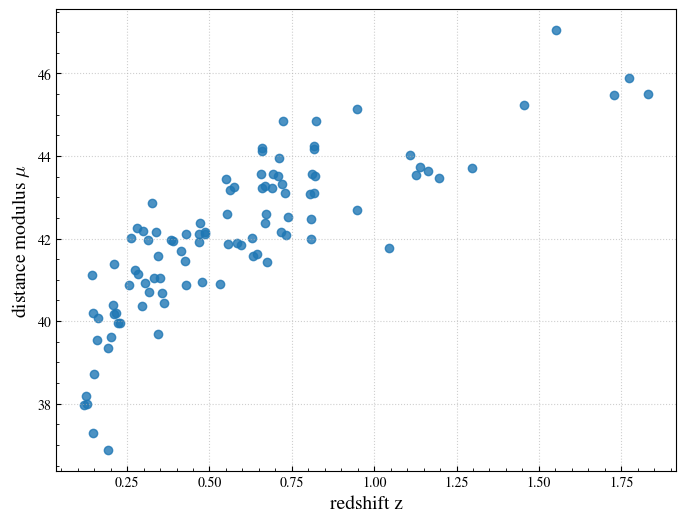

In [12]:
z_sample, mu_sample, _  = astroML.datasets.generate_mu_z(100)#, random_state=0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, mu_sample, alpha=0.8)
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
plt.grid()
plt.show()

In [3]:
X = z_sample.reshape(-1, 1)
y = mu_sample

print('Redshift z:', z_sample,'\n', 'Shape:', z_sample.shape)
print('Matrix X:', X,'\n', 'Shape:', X.shape)
print('Distance modulus mu:', y,'\n', 'Shape:', y.shape)

Redshift z: [0.52665278 0.64051274 0.7150283  0.38404094 0.40262756 0.21973581
 0.20925189 0.28697895 0.06099844 0.6058251 ] 
 Shape: (10,)
Matrix X: [[0.52665278]
 [0.64051274]
 [0.7150283 ]
 [0.38404094]
 [0.40262756]
 [0.21973581]
 [0.20925189]
 [0.28697895]
 [0.06099844]
 [0.6058251 ]] 
 Shape: (10, 1)
Distance modulus mu: [41.30597244 42.20033876 43.64614176 40.9890463  42.2704636  40.05995581
 38.86893232 41.68801651 38.34481608 41.51390857] 
 Shape: (10,)


To find the optimal parameters for our linear model, we minimize the **Residual Sum of Squares (RSS)**. The cost function $J(\theta)$ is defined as the squared norm of the residual vector:
$$J(\theta) = \|\mathbf{y} - \mathbf{X}\theta\|^2 = (\mathbf{y} - \mathbf{X}\theta)^T(\mathbf{y} - \mathbf{X}\theta)$$

Using the properties of the transpose, $(A - B)^T = A^T - B^T$, we expand the expression:

$$\begin{aligned}
J(\theta) &= (\mathbf{y}^T - \theta^T\mathbf{X}^T)(\mathbf{y} - \mathbf{X}\theta) \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\theta - \theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - 2\theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta
\end{aligned}$$

Since $\mathbf{y}^T\mathbf{X}\theta$ is a scalar, it is equal to its own transpose $(\theta^T\mathbf{X}^T\mathbf{y})$. To find the minimum, we differentiate $J(\theta)$ with respect to the parameter vector $\theta$ and set the gradient to zero:
$$\frac{\partial J(\theta)}{\partial \theta} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\theta$$

Solving for $\theta$ to find the optimal value $\hat{\theta}$:
$$\begin{aligned}
-2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\hat{\theta} &= 0 \\
\mathbf{X}^T\mathbf{X}\hat{\theta} &= \mathbf{X}^T\mathbf{y} \\
\hat{\theta} &= \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T\mathbf{y}
\end{aligned}$$

In linear regression, we seek the weights (intercept $\theta_0$ and slope $\theta_1$) that minimize the sum of squared residuals. The analytical solution is the Normal Equation:
$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{y}$$



In [4]:
# Create the design matrix by adding a column of ones for the intercept term
X_mat = np.column_stack((np.ones(X.shape[0]), X))
print('Matrix X_mat:', X_mat,'\n', 'Shape:', X_mat.shape, end='\n\n')

# Apply the normal equation to compute the coefficients
# theta = (X^T @ X)^(-1) @ X^T @ y
theta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y
print('Intercept (theta[0]):', theta[0])
print('Slope (theta[1]):', theta[1])

Matrix X_mat: [[1.         0.52665278]
 [1.         0.64051274]
 [1.         0.7150283 ]
 [1.         0.38404094]
 [1.         0.40262756]
 [1.         0.21973581]
 [1.         0.20925189]
 [1.         0.28697895]
 [1.         0.06099844]
 [1.         0.6058251 ]] 
 Shape: (10, 2)

Intercept (theta[0]): 38.46929875973257
Slope (theta[1]): 6.465165638125665


In [5]:
z_fit  = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100)
X_fit  = np.column_stack((np.ones(z_fit.shape[0]), z_fit.reshape(-1, 1)))
mu_fit = X_fit @ theta 

To measure the accuracy of our model, we calculate the **Mean Squared Error** (MSE). This metric tells us, on average, how far our predictions are from the true astronomical observations
$$\text{MSE}=\frac{1}{n}\sum_{i=1}^{n} \left(y_i - \hat y_i\right)^2$$

where $n$ is the total number of data point, $y_i$ is the real (observed) value, and $\hat y_i$ is the predicted value by the model

In [6]:
mse = np.mean((X_mat @ theta - y) ** 2)
print('Mean Squared Error:', mse)

Mean Squared Error: 0.6060883774079386


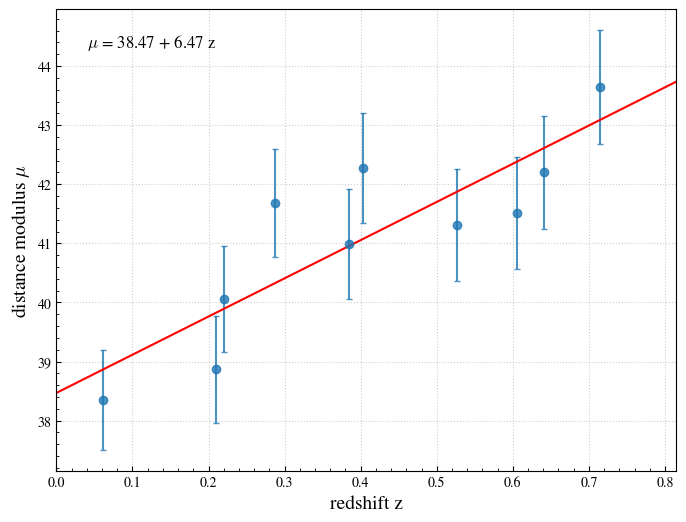

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, mu_sample, alpha=0.8)
ax.plot(z_fit, mu_fit, color='red', label='Linear Fit')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
ax.text(0.05, 0.95, fr'$\mu$ = {theta[0]:.2f} + {theta[1]:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
#ax.legend()
plt.grid()
plt.show()

Libraries such as `scikit-learn` and `SciPy` already have these methods implemented. In this lecture, we will prioritize `scikit-learn` because it is the standard for Machine Learning and will be used frequently throughout the rest of this course. However, we also encourage you to explore the `SciPy` documentation.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X, y)

intercept_sklearn = model.intercept_
slope_sklearn     = model.coef_[0]

print('Intercept (sklearn):', intercept_sklearn)
print('Slope (sklearn):', slope_sklearn)

y_fit_sklearn = model.predict(X)
mse_sklearn = mean_squared_error(y, y_fit_sklearn)
print('MSE (sklearn):', mse_sklearn)

Intercept (sklearn): 38.46929875973251
Slope (sklearn): 6.465165638125661
MSE (sklearn): 0.6060883774079376


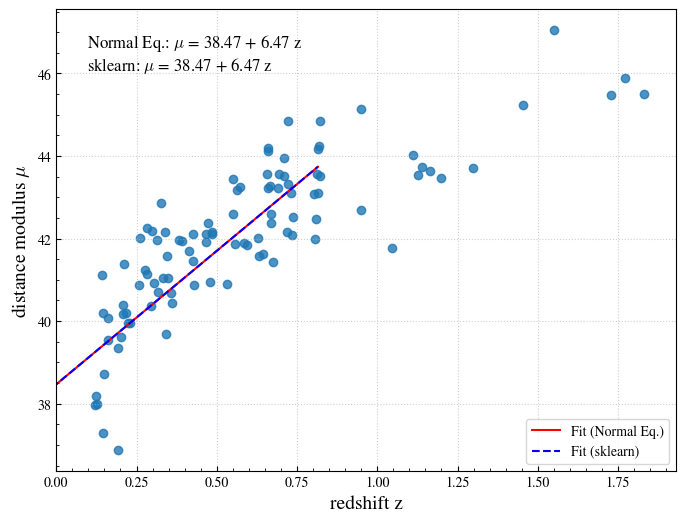

In [13]:
theta_sklearn  = np.array([intercept_sklearn, slope_sklearn])
mu_fit_sklearn = X_fit @ theta 


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, mu_sample, alpha=0.8)
ax.plot(z_fit, mu_fit, color='red', label='Fit (Normal Eq.)')
ax.plot(z_fit, mu_fit_sklearn, color='blue', linestyle='--', label='Fit (sklearn)')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
ax.text(0.05, 0.95, fr'Normal Eq.: $\mu$ = {theta[0]:.2f} + {theta[1]:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.90, fr'sklearn: $\mu$ = {intercept_sklearn:.2f} + {slope_sklearn:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
ax.legend()
plt.grid()
plt.show()

**General Case:** TThe OLS derivation assumes that all errors are equal and independent of each other. However, in real astronomical data, this is rarely true. Each observation typically has a different uncertainty, requiring us to work with the Covariance Matrix $\mathbf{C}$:

$$\mathbf{C} = \begin{bmatrix} 
\sigma_1^2 & \sigma_{12} & \dots & \sigma_{1n} \\
\sigma_{21} & \sigma_2^2 & \dots & \sigma_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{n1} & \sigma_{n2} & \dots & \sigma_n^2 
\end{bmatrix}$$

In this case, the cost function $J(\theta)$ (often referred to as $\chi^2$ in astronomy) is weighted by the inverse of the covariance matrix:

$$J(\theta) = (\mathbf{y} - \mathbf{X}\theta)^T \mathbf{C}^{-1} (\mathbf{y} - \mathbf{X}\theta)$$

The general solution for the optimal parameters, known as Weighted Least Squares, is:
$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{C}^{-1}\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{C}^{-1} \mathbf{y}$$

Ordinary Mean Saquere

Preguntas para ustedes,

¿Qué pasa si usamos todo el set de datos para entrenar y nada para testear?

¿Por qué OLS tiene problemas con datos complejos?

# Regularization: Ridge and Lasso

OLS could perfom an overfitting when there is a lot noise. What could in that case

There are two options



- **Lasso Regression ($L_1$ Regularization):** Let ones coefficents in 0 to improve the model.


The penalizes:

$$J(\theta) = \text{MSE} + \alpha \sum_{i=1}^n |\theta_i|$$

- **Ridge Regularization ($L_2$ Regularization):** Penalizes hihg coefficents but keep all caracteristic in the sample

$$J(\theta) = \text{MSE} + \alpha \sum_{i=1}^n \theta_i^2$$

In [10]:
from sklearn.linear_model import Ridge, Lasso

# Fit Lasso and Ridge
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Predecimos
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# Comparamos modelos
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS")
plt.plot(X_test, y_pred_lasso, color="blue", linestyle="dashed", label="Lasso")
plt.plot(X_test, y_pred_ridge, color="yellow", linestyle="dotted", label="Ridge")
plt.legend()
plt.show()

NameError: name 'X_train' is not defined

¿Cuándo deberíamos usar Lasso en lugar de Ridge?

Lasso es útil cuando esperamos que solo unas pocas características sean realmente importantes, ya que puede eliminar algunas estableciendo sus coeficientes en cero (soluciones dispersas).

Ridge es mejor cuando todas las características son relevantes, pero necesitamos reducir su impacto para evitar el sobreajuste (overfitting).

Ejemplo en Astronomía: Si tenemos un conjunto de datos de espectros de galaxias con muchas longitudes de onda, Lasso puede seleccionar las bandas más importantes. Ridge, en cambio, asegurará que todas las bandas contribuyan, pero con menor influencia.

Manejo de outliers: Regresión de Huber
Si tenemos outliers, OLS no hace el fit correctamente, pues los errores son muy grandes.

Así, la regresión de Huber combina OLS con una perdida absoluta, de esta forma puede manejar los outlier y ser más robusta.

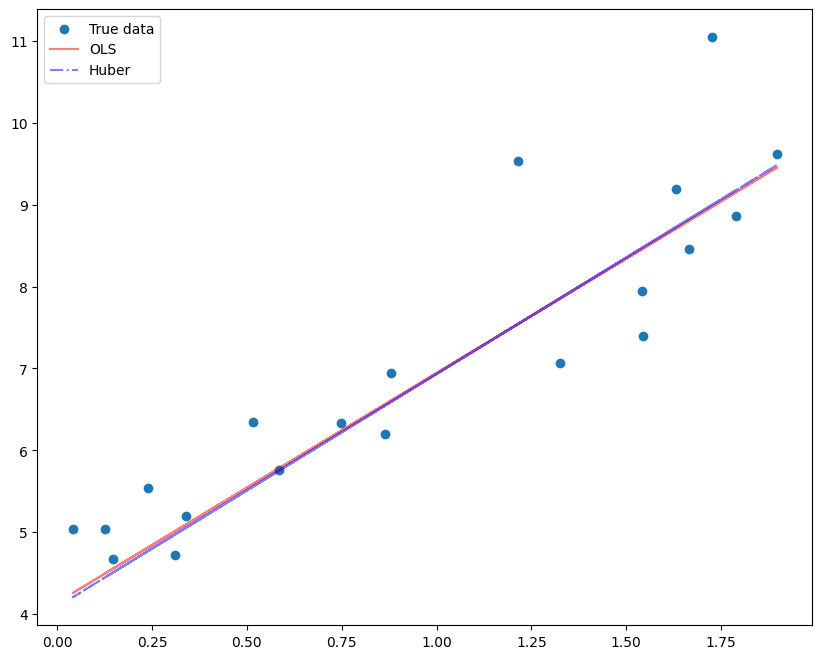

In [ ]:
from sklearn.linear_model import HuberRegressor

# Agregamos outliers a la muestra
y_outliers = y.copy()
y_outliers[95:] += 10  # Agregamos errores grandes

# Fit Huber Regression
huber = HuberRegressor()
huber.fit(X_train, y_train.ravel())

# Predecimos
y_pred_huber = huber.predict(X_test)

# Comparamos modelos
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS", alpha=0.5)
plt.plot(X_test, y_pred_huber, color="blue", linestyle="dashdot",
         label="Huber",alpha=0.5)
plt.legend()
plt.show()

| Methodology | Description |
|------------|-------------|
| OLS        | Use this as a baseline for well-behaved, linear datasets where you expect Gaussian noise and no significant outliers. |
| Ridge      | Useful when features are highly correlated (e.g., multiple galaxy color indices) |
| Lasso      | Ideal for automatic feature selection (e.g., identifying the most relevant spectral lines). |
| Huber      | Robust against measurement errors and extreme values (e.g., observations of variable stars). |

In [ ]:
# Fetching real galaxy data
data = astroML.datasets.fetch_nasa_atlas()

In [ ]:
mask = (data['VDISP'] > 0) & (data['Z'] > 0) & (data['PETROTH50'] > 0)
data = data[mask]
data = pd.DataFrame({
    # Convertimos el radio angular a radio físico aproximado usando el redshift (Z)
    'log_Re': np.log10(data['PETROTH50'] * data['Z']),
    # Logaritmo de la dispersión de velocidades
    'log_sigma': np.log10(data['VDISP']),
    # Magnitud absoluta en banda r (índice 4 del vector ABSMAG)
    'Mr': data['ABSMAG'][:,4]
})
data = data.replace([np.inf, -np.inf], np.nan).dropna()
data.reset_index(drop=True, inplace=True)
data = data[:100]  # Limitamos a 1000 galaxias para acelerar el proceso
data.shape, data.columns, data.head()

((100, 3),
 Index(['log_Re', 'log_sigma', 'Mr'], dtype='str'),
      log_Re  log_sigma         Mr
 0 -1.133606   2.120125 -19.667040
 1 -0.918776   1.621217 -18.400158
 2 -1.346841   1.199230 -15.508064
 3 -0.763240   2.018366 -20.400579
 4 -1.076029   1.744785 -16.589527)

$$\log R_e = \theta_0 + \theta_1 \log \sigma + \theta_2 \mu$$

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Defined the features (X) and target variable (y)
X = data[['log_sigma','Mr']]
y = data['log_Re']

model = LinearRegression()
model.fit(X.values, y)

y_pred = model.predict(X)
mse    = mean_squared_error(y, y_pred)

print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean Squared Error:', mse)

Coefficients: [-0.20775138 -0.08169744]
Intercept: -2.1061428
Mean Squared Error: 0.043693531304597855


/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


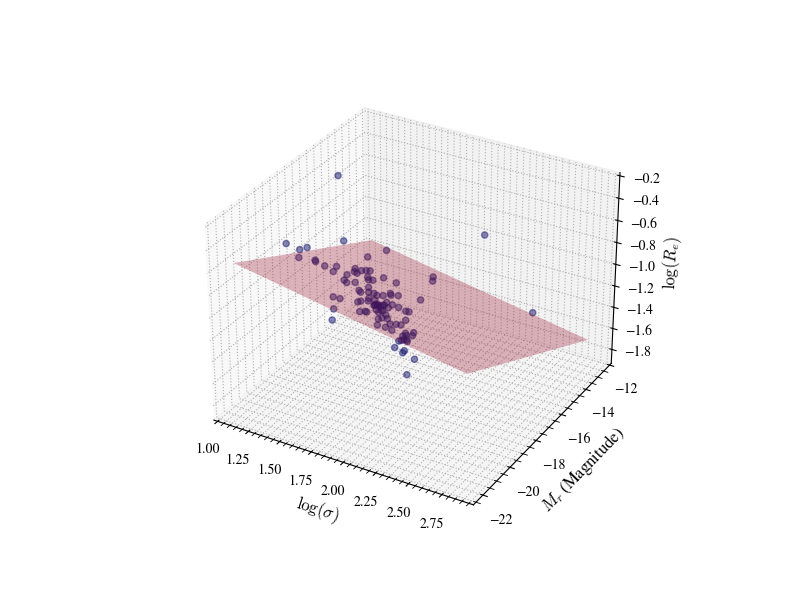

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': '3d'})

ax.scatter(data['log_sigma'], data['Mr'], data['log_Re'], 
           color='midnightblue', alpha=0.5, label='Galaxies')

# 2. Creamos la malla para representar el plano de ajuste
x_range = np.linspace(data['log_sigma'].min(), data['log_sigma'].max(), 20)
y_range = np.linspace(data['Mr'].min(), data['Mr'].max(), 20)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)

# Predicción sobre la malla (necesitamos aplanarla para el modelo)
mesh_points = np.c_[x_mesh.ravel(), y_mesh.ravel()]
z_mesh = model.predict(mesh_points).reshape(x_mesh.shape)

# 3. Graficamos el plano (superficie)
ax.plot_surface(x_mesh, y_mesh, z_mesh, color='crimson', alpha=0.3)

# Etiquetas y Estilo
ax.set_xlabel(r'$\log(\sigma)$', fontsize=12)
ax.set_ylabel(r'$M_r$ (Magnitude)', fontsize=12)
ax.set_zlabel(r'$\log(R_e)$', fontsize=12)

plt.show()